# Analyse Approfondie des Vaisseaux Hépatiques — Segmentation

Ce notebook complète l'analyse GT existante avec des visualisations orientées **segmentation** :
- Profils de rayon le long du squelette (taille locale)
- Distribution jointe taille × intensité HU
- Cartes 2D rayon/intensité par type de vaisseau
- Seuils optimaux pour distinguer les vaisseaux du foie
- Analyse de séparabilité inter-classes
- Statistiques par tranches de calibre (petits / moyens / gros vaisseaux)
- Overlays multi-coupes avec profils d'intensité

## 0. Installation des dépendances

In [ ]:
import subprocess, sys

packages = [
    'nibabel', 'numpy', 'pandas', 'matplotlib', 'seaborn',
    'scipy', 'scikit-image', 'tqdm', 'plotly', 'kaleido'
]
for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print(' Dépendances prêtes')

✅ Dépendances prêtes



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 1. Imports & Configuration

In [ ]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, Normalize, LogNorm
from matplotlib.patches import Patch
import seaborn as sns

from scipy import ndimage, stats
from scipy.ndimage import distance_transform_edt
from skimage import measure, morphology
from skimage.morphology import skeletonize
from tqdm.auto import tqdm

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ──────────────────────────────────────────────
#  CONFIGURATION  ← Modifier selon votre projet
# ──────────────────────────────────────────────
DATA_ROOT  = '/Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/données_pretraitées'
N_PATIENTS = 20
OUTPUT_DIR = '/Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/resultats_vaisseaux_deep'
os.makedirs(OUTPUT_DIR, exist_ok=True)

VESSEL_LABELS = {
    1: {'name': 'artery',   'display': 'Artère',             'color': '#E41A1C', 'file_key': 'artery'},
    2: {'name': 'portal',   'display': 'Veine porte',        'color': '#377EB8', 'file_key': 'portal'},
    3: {'name': 'venous',   'display': 'Venous',   'color': '#4DAF4A', 'file_key': 'venous'},
    4: {'name': 'venacava', 'display': 'Veine cave',         'color': '#984EA3', 'file_key': 'venacava'},
}

# Calibres (mm) — seuils pour classifier petits/moyens/gros vaisseaux
RADIUS_BINS = [0, 0.5, 1.0, 2.5, 5.0, np.inf]
RADIUS_LABELS = ['< 0.5 mm', '0.5–1 mm', '1–2.5 mm', '2.5–5 mm', '> 5 mm']

sns.set_theme(style='whitegrid', font_scale=1.05)
print(f' DATA_ROOT  : {DATA_ROOT}')
print(f' OUTPUT_DIR : {OUTPUT_DIR}')

📁 DATA_ROOT  : /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/données_pretraitées
📁 OUTPUT_DIR : /Users/arslenebouhadjera/Stage_Arslène_2026/Documents/StageNoé2025/pipeline-vessel-enhancement-master/resultats_vaisseaux_deep


## 2. Fonctions Utilitaires

In [ ]:
def get_files(pid: str) -> dict:
    base = os.path.join(DATA_ROOT, f'patient_{pid}')
    return {
        'ct':       os.path.join(base, f'patient_{pid}_ct_isotropic.nii.gz'),
        'liver':    os.path.join(base, f'patient_{pid}_liver_mask_isotropic.nii.gz'),
        'artery':   os.path.join(base, f'patient_{pid}_vessel_artery__in_liver_isotropic.nii.gz'),
        'portal':   os.path.join(base, f'patient_{pid}_vessel_portalvein__in_liver_isotropic.nii.gz'),
        'venous':   os.path.join(base, f'patient_{pid}_vessel_venous__in_liver_isotropic.nii.gz'),
        'venacava': os.path.join(base, f'patient_{pid}_vessel_venacava__in_liver_isotropic.nii.gz'),
        'gt':       os.path.join(base, f'patient_{pid}_vessels_gt_isotropic_in_liver.nii.gz'),
    }


def load_nifti(path: str):
    """Charge NIfTI → (data, zooms). Retourne (None, None) si absent."""
    if not path or not os.path.exists(path):
        return None, None
    img   = nib.load(path)
    data  = img.get_fdata()
    zooms = np.array(img.header.get_zooms()[:3], dtype=float)
    return data, zooms


def get_valid_patients() -> list:
    valid = []
    for i in range(1, N_PATIENTS + 1):
        pid = f'{i:02d}'
        f = get_files(pid)
        if os.path.exists(f['ct']) and os.path.exists(f['liver']):
            valid.append(pid)
    return valid


# ─── Squelette + rayon + HU le long du squelette ───────────────
def extract_skeleton_profile(mask: np.ndarray, ct: np.ndarray, zooms: np.ndarray) -> dict:
    """
    Calcule pour chaque voxel du squelette :
      - rayon local (EDT sur masque)
      - intensité HU CT
    Retourne un dict avec tableaux numpy.
    """
    if mask.sum() == 0:
        return {'radii': np.array([]), 'hu': np.array([])}

    skel   = skeletonize(mask > 0)
    edt    = distance_transform_edt(mask, sampling=zooms.tolist())
    radii  = edt[skel > 0]
    hu_val = ct[skel > 0]
    return {'radii': radii, 'hu': hu_val}


# ─── EDT sur tout le masque (tous les voxels) ──────────────────
def extract_voxel_profile(mask: np.ndarray, ct: np.ndarray, zooms: np.ndarray) -> dict:
    """
    Pour chaque voxel du masque : rayon local (= distance au bord du vaisseau)
    et intensité HU.
    """
    if mask.sum() == 0:
        return {'radii': np.array([]), 'hu': np.array([])}
    edt = distance_transform_edt(mask, sampling=zooms.tolist())
    return {
        'radii': edt[mask > 0],
        'hu':    ct[mask > 0],
    }


valid_patients = get_valid_patients()
print(f' Patients valides : {len(valid_patients)} → {valid_patients}')

✅ Patients valides : 20 → ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


## 3. Extraction du Profil Rayon × Intensité (tous patients)

In [ ]:
# Collecte des profils rayon + HU par type de vaisseau
# Pour chaque voxel du squelette : rayon + HU

profiles = {lbl: {'radii': [], 'hu': [], 'patient': []} for lbl in VESSEL_LABELS}
profiles_all_voxels = {lbl: {'radii': [], 'hu': []} for lbl in VESSEL_LABELS}   # tous voxels masque

# Parenchyme hépatique (hors vaisseaux) — pour comparaison
parenchyma_hu = []

print(' Extraction des profils rayon/intensité...')
for pid in tqdm(valid_patients, desc='Patients'):
    f = get_files(pid)
    ct, zooms = load_nifti(f['ct'])
    liver, _  = load_nifti(f['liver'])
    if ct is None or liver is None:
        continue

    liver_mask = (liver > 0)

    # Parenchyme = foie sans aucun vaisseau
    all_vessels = np.zeros_like(liver_mask, dtype=bool)

    for lbl, info in VESSEL_LABELS.items():
        mask_data, _ = load_nifti(f[info['file_key']])
        if mask_data is None:
            continue
        mask = (mask_data > 0).astype(np.uint8)
        all_vessels |= (mask > 0)

        # Profil squelette
        prof = extract_skeleton_profile(mask, ct, zooms)
        profiles[lbl]['radii'].extend(prof['radii'])
        profiles[lbl]['hu'].extend(prof['hu'])
        profiles[lbl]['patient'].extend([pid] * len(prof['radii']))

        # Profil tous voxels
        vp = extract_voxel_profile(mask, ct, zooms)
        profiles_all_voxels[lbl]['radii'].extend(vp['radii'])
        profiles_all_voxels[lbl]['hu'].extend(vp['hu'])

    # Parenchyme hépatique (foie - vaisseaux)
    parenchyma = liver_mask & (~all_vessels)
    sample_idx = np.where(parenchyma)
    n_sample = min(5000, len(sample_idx[0]))
    if n_sample > 0:
        idx = np.random.choice(len(sample_idx[0]), n_sample, replace=False)
        parenchyma_hu.extend(ct[sample_idx[0][idx], sample_idx[1][idx], sample_idx[2][idx]])

# Convertir en numpy
for lbl in VESSEL_LABELS:
    for k in ['radii', 'hu']:
        profiles[lbl][k]            = np.array(profiles[lbl][k])
        profiles_all_voxels[lbl][k] = np.array(profiles_all_voxels[lbl][k])

parenchyma_hu = np.array(parenchyma_hu)
print('\n Profils extraits :')
for lbl, info in VESSEL_LABELS.items():
    n = len(profiles[lbl]['radii'])
    print(f"  {info['display']:22s} : {n:>7,} points squelette")

🔄 Extraction des profils rayon/intensité...


Patients:   0%|          | 0/20 [00:00<?, ?it/s]


✅ Profils extraits :
  Artère                 :  24,790 points squelette
  Veine porte            :  63,125 points squelette
  Venous                 :  47,018 points squelette
  Veine cave             :  21,506 points squelette


## 4. Distribution des Rayons par Type de Vaisseau

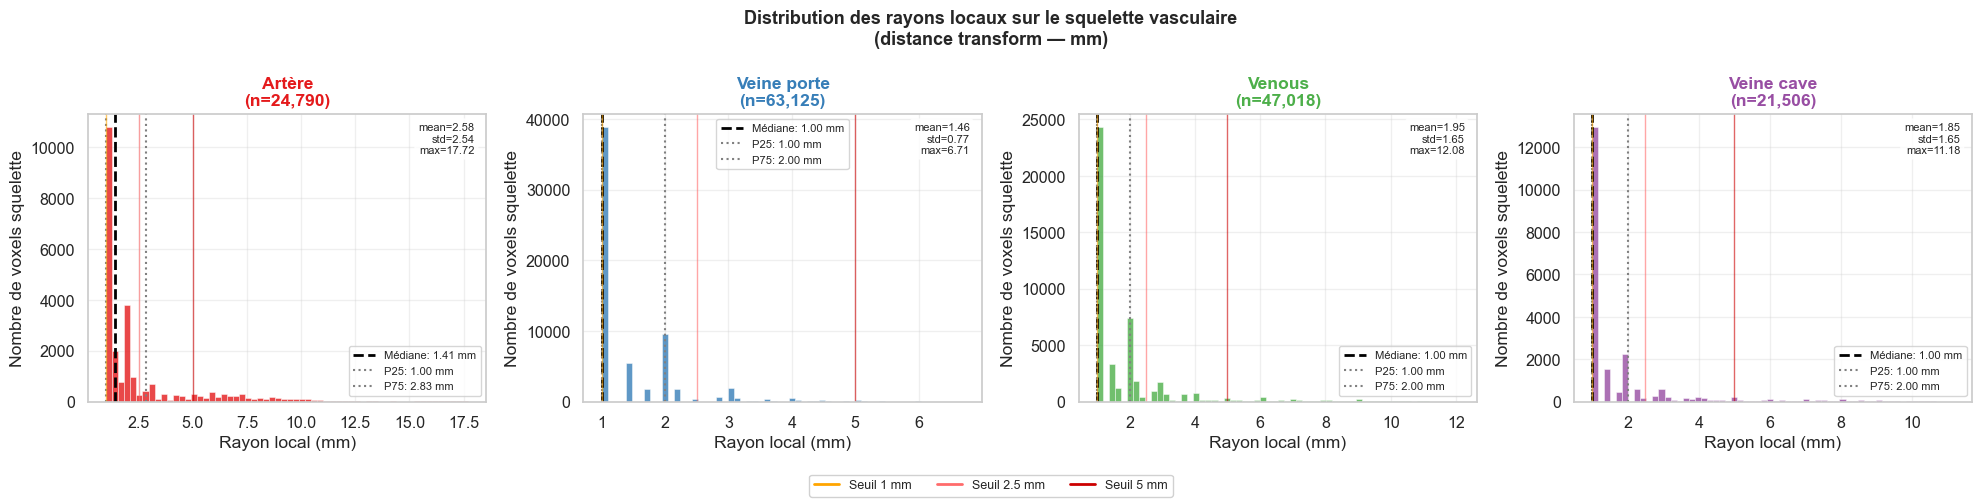

In [54]:
# ─── Fig 1 : Distributions des rayons (squelette) ──────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
fig.suptitle('Distribution des rayons locaux sur le squelette vasculaire\n(distance transform — mm)',
             fontsize=13, fontweight='bold')

for ax, (lbl, info) in zip(axes, VESSEL_LABELS.items()):
    r = profiles[lbl]['radii']
    r = r[r > 0]
    if len(r) == 0:
        ax.text(0.5, 0.5, 'Aucune donnée', ha='center', va='center',
                transform=ax.transAxes)
        continue

    ax.hist(r, bins=60, color=info['color'], alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.axvline(np.median(r), color='black', ls='--', lw=2, label=f'Médiane: {np.median(r):.2f} mm')
    ax.axvline(np.percentile(r, 25), color='gray', ls=':', lw=1.5,
               label=f'P25: {np.percentile(r,25):.2f} mm')
    ax.axvline(np.percentile(r, 75), color='gray', ls=':', lw=1.5,
               label=f'P75: {np.percentile(r,75):.2f} mm')

    # Seuils de calibre
    for thresh, col in zip([1.0, 2.5, 5.0], ['#FFA500', '#FF6B6B', '#CC0000']):
        ax.axvline(thresh, color=col, ls='-', lw=1, alpha=0.6)

    ax.set_title(f"{info['display']}\n(n={len(r):,})", fontweight='bold', color=info['color'])
    ax.set_xlabel('Rayon local (mm)')
    ax.set_ylabel('Nombre de voxels squelette')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Statistiques
    txt = f"mean={r.mean():.2f}\nstd={r.std():.2f}\nmax={r.max():.2f}"
    ax.text(0.97, 0.97, txt, transform=ax.transAxes, va='top', ha='right',
            fontsize=8, bbox=dict(boxstyle='round', fc='white', alpha=0.8))

# Légende des seuils de calibre
from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0],[0], color='#FFA500', lw=2, label='Seuil 1 mm'),
    Line2D([0],[0], color='#FF6B6B', lw=2, label='Seuil 2.5 mm'),
    Line2D([0],[0], color='#CC0000', lw=2, label='Seuil 5 mm'),
]
fig.legend(handles=legend_lines, loc='lower center', ncol=3, fontsize=9, framealpha=0.9)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, 'fig01_radius_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

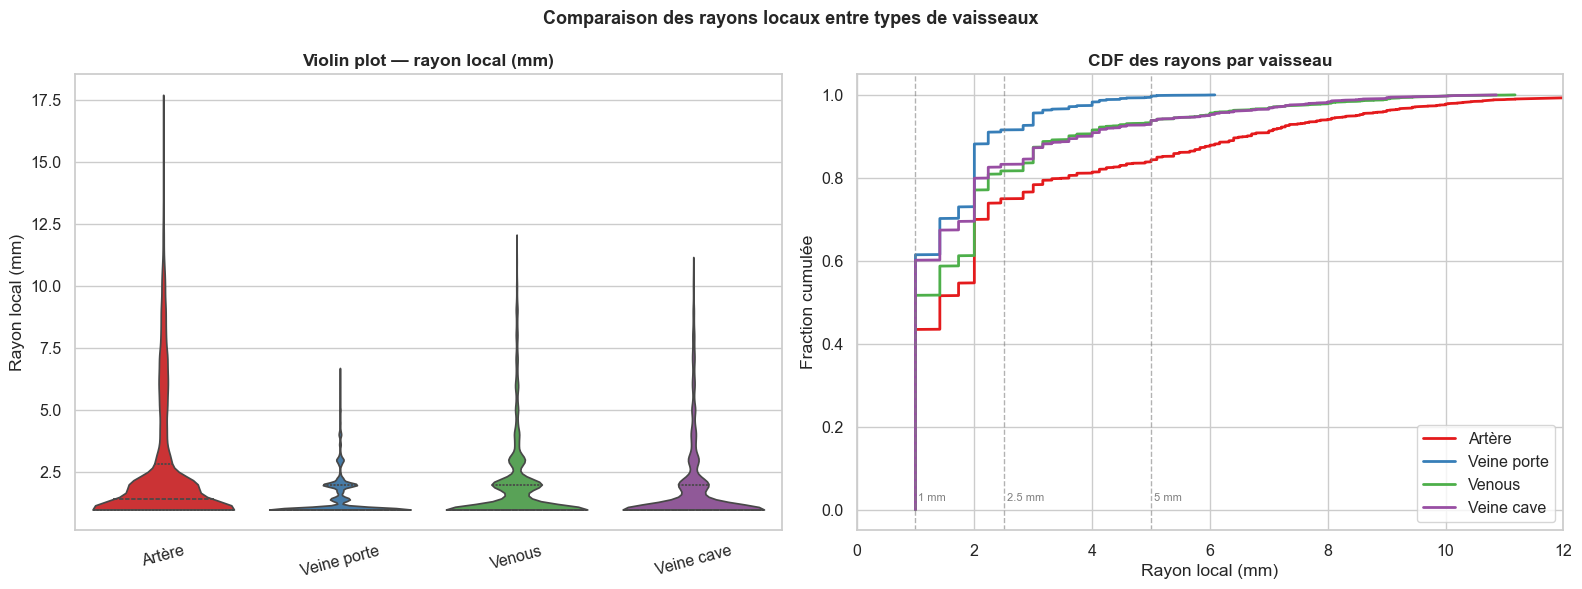

In [55]:
# ─── Fig 2 : Violinplot comparatif des rayons ──────────────────
violin_data = []
for lbl, info in VESSEL_LABELS.items():
    r = profiles[lbl]['radii']
    r = r[(r > 0) & (r < 20)]   # clip outliers extrêmes
    violin_data.append(pd.DataFrame({
        'rayon_mm': r,
        'vaisseau': info['display']
    }))
violin_df = pd.concat(violin_data, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison des rayons locaux entre types de vaisseaux', fontsize=13, fontweight='bold')

colors_list = [VESSEL_LABELS[lbl]['color'] for lbl in sorted(VESSEL_LABELS)]
palette = {info['display']: info['color'] for info in VESSEL_LABELS.values()}

# Violin
sns.violinplot(data=violin_df, x='vaisseau', y='rayon_mm', palette=palette,
               inner='quartile', ax=axes[0], cut=0)
axes[0].set_title('Violin plot — rayon local (mm)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Rayon local (mm)')
axes[0].tick_params(axis='x', rotation=15)

# CDF cumulée
for lbl, info in VESSEL_LABELS.items():
    r = np.sort(profiles[lbl]['radii'])
    r = r[r > 0]
    if len(r) == 0:
        continue
    cdf = np.arange(1, len(r)+1) / len(r)
    # Subsample pour ne pas tracer 1M de points
    step = max(1, len(r)//2000)
    axes[1].plot(r[::step], cdf[::step], color=info['color'], lw=2, label=info['display'])

for thresh, lbl_t in zip([1.0, 2.5, 5.0], ['1 mm', '2.5 mm', '5 mm']):
    axes[1].axvline(thresh, color='gray', ls='--', lw=1, alpha=0.6)
    axes[1].text(thresh+0.05, 0.02, lbl_t, fontsize=8, color='gray')

axes[1].set_title('CDF des rayons par vaisseau', fontweight='bold')
axes[1].set_xlabel('Rayon local (mm)')
axes[1].set_ylabel('Fraction cumulée')
axes[1].legend()
axes[1].set_xlim(0, 12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig02_radius_violin_cdf.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Distribution des Intensités HU

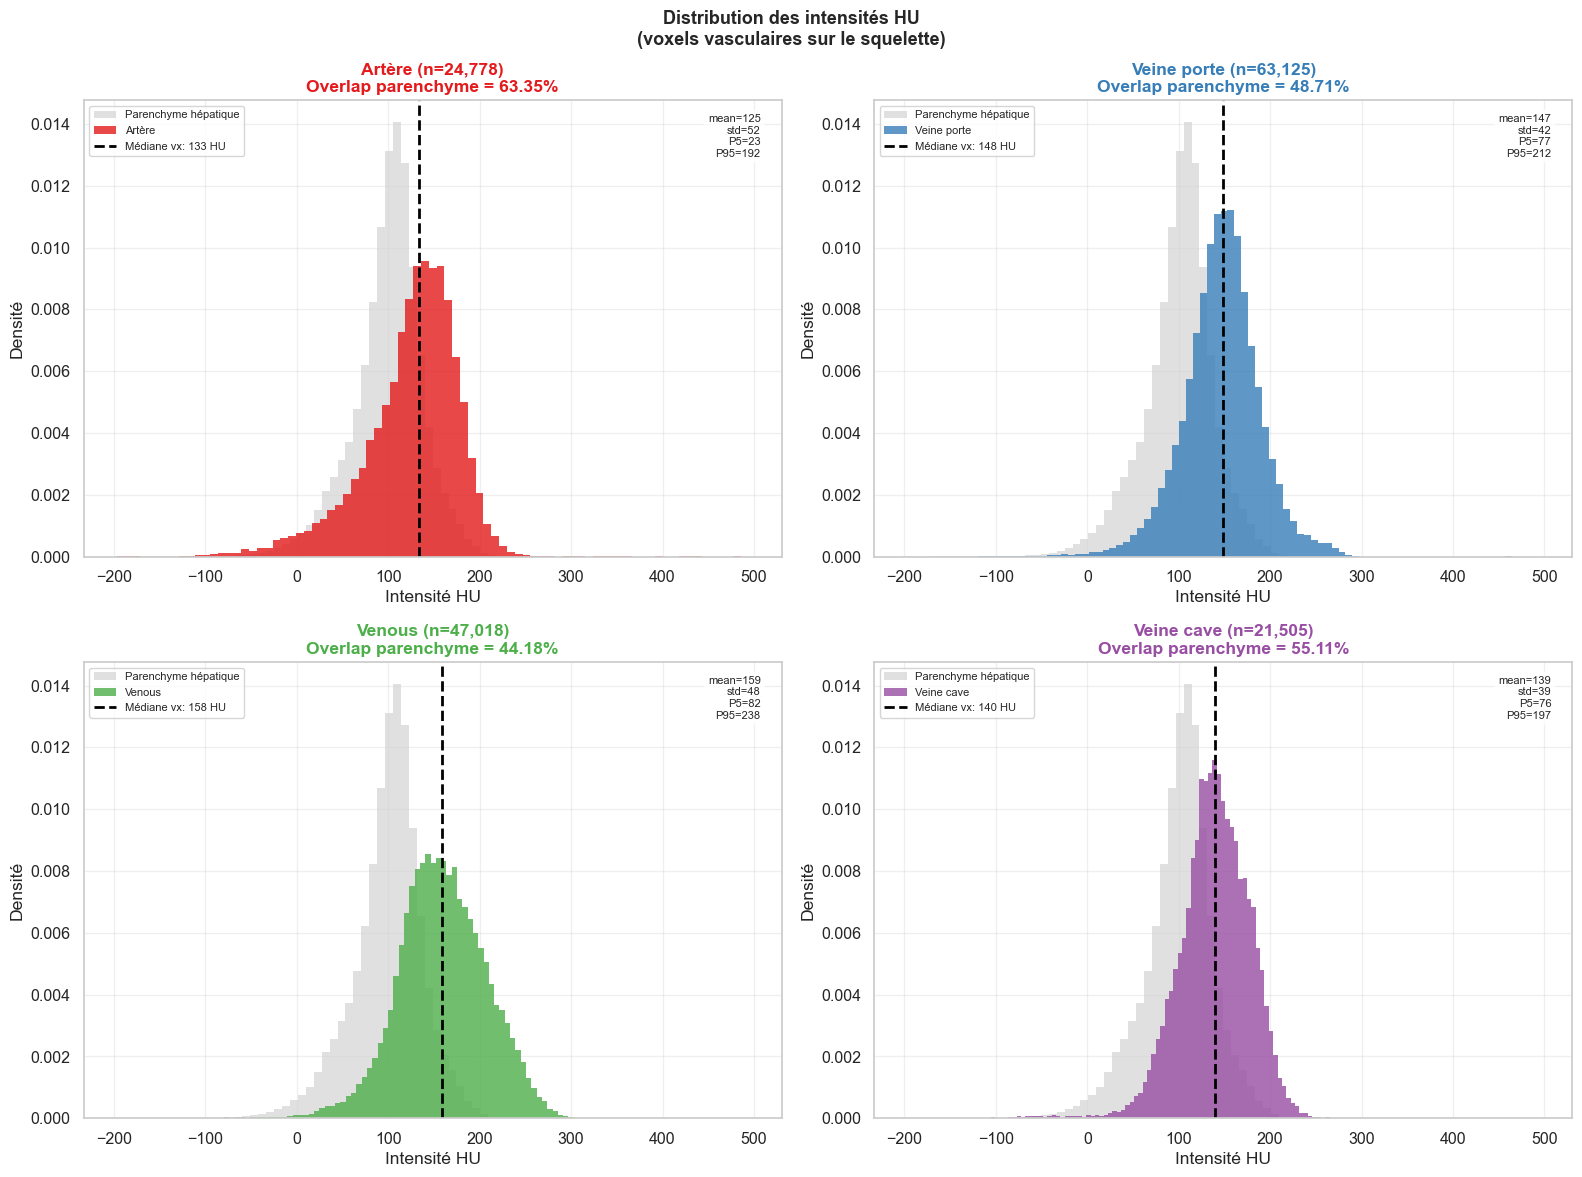

In [56]:
# ─── Fig 3 : HU distributions — vaisseaux vs parenchyme ────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution des intensités HU\n(voxels vasculaires sur le squelette)',
             fontsize=13, fontweight='bold')

HU_RANGE = (-200, 500)

for ax, (lbl, info) in zip(axes.flat, VESSEL_LABELS.items()):
    hu = profiles[lbl]['hu']
    hu = hu[(hu > HU_RANGE[0]) & (hu < HU_RANGE[1])]
    if len(hu) == 0:
        continue

    # Parenchyme
    parc = parenchyma_hu[(parenchyma_hu > HU_RANGE[0]) & (parenchyma_hu < HU_RANGE[1])]
    ax.hist(parc, bins=80, color='lightgray', alpha=0.7, label='Parenchyme hépatique',
            density=True, edgecolor='none')
    ax.hist(hu, bins=80, color=info['color'], alpha=0.8, label=info['display'],
            density=True, edgecolor='none')

    ax.axvline(np.median(hu), color='black', ls='--', lw=2,
               label=f'Médiane vx: {np.median(hu):.0f} HU')

    # Overlap
    min_p, max_p = min(hu.min(), parc.min()), max(hu.max(), parc.max())
    bins_e = np.linspace(min_p, max_p, 100)
    h1, _ = np.histogram(hu, bins=bins_e, density=True)
    h2, _ = np.histogram(parc, bins=bins_e, density=True)
    overlap = np.trapz(np.minimum(h1, h2), bins_e[:-1])

    ax.set_title(f"{info['display']} (n={len(hu):,})\nOverlap parenchyme = {overlap:.2%}",
                 fontweight='bold', color=info['color'])
    ax.set_xlabel('Intensité HU')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Stats
    txt = f"mean={hu.mean():.0f}\nstd={hu.std():.0f}\nP5={np.percentile(hu,5):.0f}\nP95={np.percentile(hu,95):.0f}"
    ax.text(0.97, 0.97, txt, transform=ax.transAxes, va='top', ha='right',
            fontsize=8, bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig03_hu_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

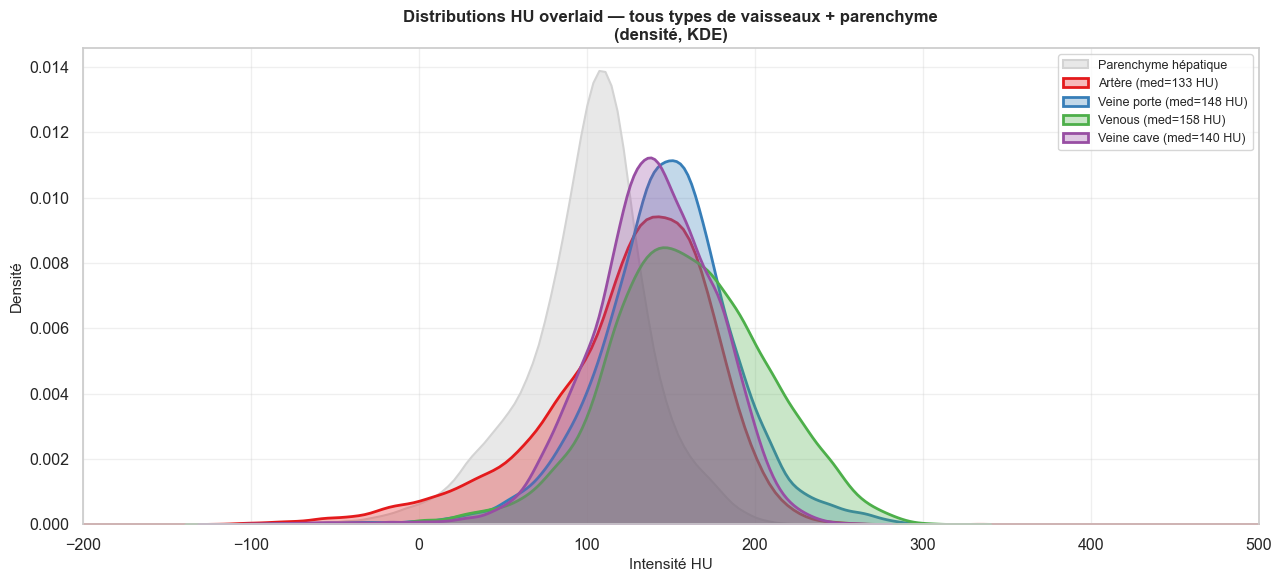

In [57]:
# ─── Fig 4 : HU comparatif overlaid + KDE ──────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_title('Distributions HU overlaid — tous types de vaisseaux + parenchyme\n(densité, KDE)',
             fontsize=12, fontweight='bold')

parc = parenchyma_hu[(parenchyma_hu > -200) & (parenchyma_hu < 500)]
sns.kdeplot(parc, color='lightgray', fill=True, alpha=0.5, label='Parenchyme hépatique',
            linewidth=1.5, ax=ax)

for lbl, info in VESSEL_LABELS.items():
    hu = profiles[lbl]['hu']
    hu = hu[(hu > -200) & (hu < 500)]
    if len(hu) < 10:
        continue
    # Subsample
    if len(hu) > 20000:
        hu = np.random.choice(hu, 20000, replace=False)
    sns.kdeplot(hu, color=info['color'], fill=True, alpha=0.3,
                label=f"{info['display']} (med={np.median(profiles[lbl]['hu']):.0f} HU)",
                linewidth=2, ax=ax)

ax.set_xlabel('Intensité HU', fontsize=11)
ax.set_ylabel('Densité', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(-200, 500)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig04_hu_kde_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Carte 2D Rayon × Intensité HU (Joint Distribution)

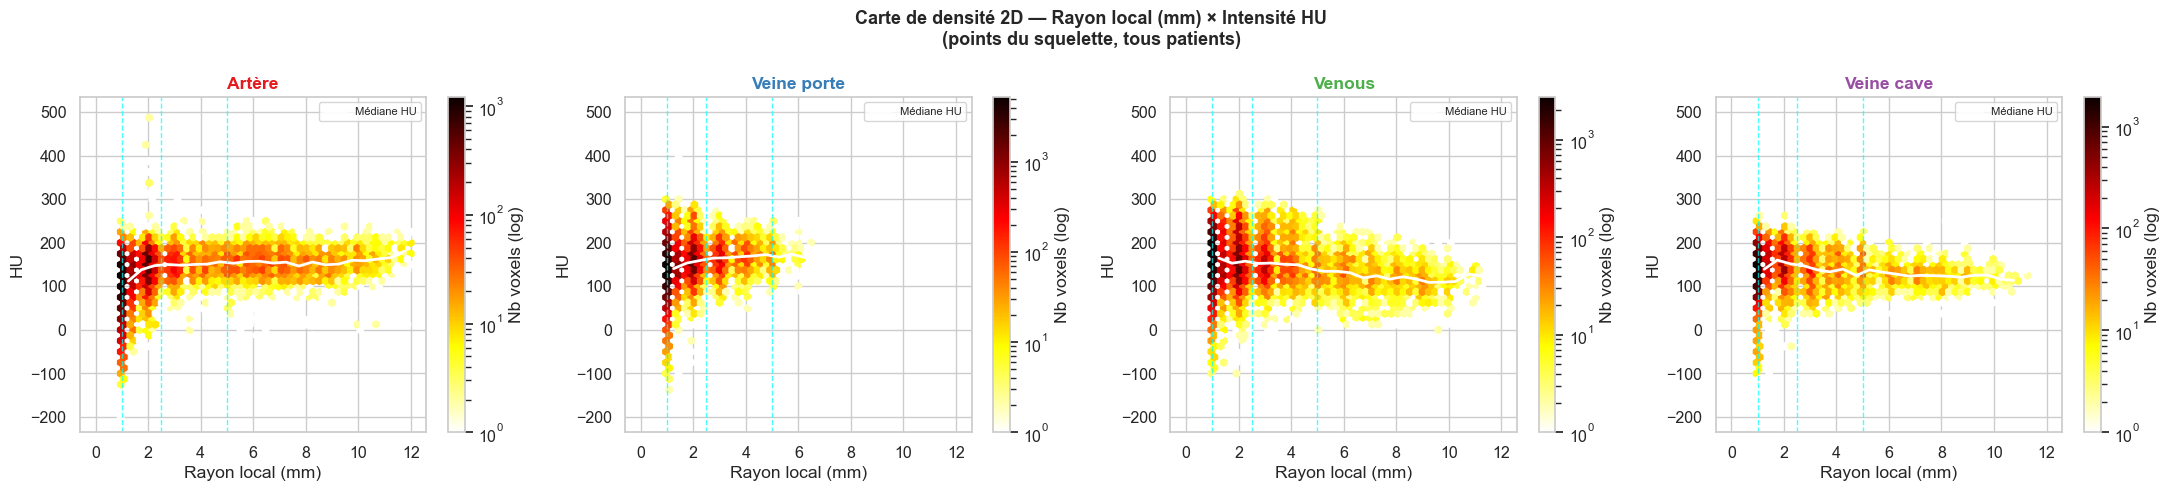

In [58]:
# ─── Fig 5 : Density map 2D rayon × HU (hexbin) ────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Carte de densité 2D — Rayon local (mm) × Intensité HU\n(points du squelette, tous patients)',
             fontsize=13, fontweight='bold')

for ax, (lbl, info) in zip(axes, VESSEL_LABELS.items()):
    r  = profiles[lbl]['radii']
    hu = profiles[lbl]['hu']
    mask_valid = (r > 0) & (r < 15) & (hu > -200) & (hu < 500)
    r, hu = r[mask_valid], hu[mask_valid]

    if len(r) < 10:
        ax.text(0.5, 0.5, 'Aucune donnée', ha='center', va='center', transform=ax.transAxes)
        continue

    hb = ax.hexbin(r, hu, gridsize=50, mincnt=1, cmap='hot_r',
                   norm=LogNorm(vmin=1),
                   extent=[0, 12, -200, 500])
    plt.colorbar(hb, ax=ax, label='Nb voxels (log)')

    # Médiane de HU par tranche de rayon
    bins = np.arange(0, 12.5, 0.5)
    bin_centers, medians, stds = [], [], []
    for b0, b1 in zip(bins[:-1], bins[1:]):
        sel = hu[(r >= b0) & (r < b1)]
        if len(sel) > 5:
            bin_centers.append((b0+b1)/2)
            medians.append(np.median(sel))
            stds.append(np.std(sel))
    if bin_centers:
        ax.plot(bin_centers, medians, 'w-', lw=2, label='Médiane HU')
        ax.fill_betweenx(
            np.array(medians),
            np.array(bin_centers) - 0.15,
            np.array(bin_centers) + 0.15,
            alpha=0, color='none'
        )

    ax.set_title(f"{info['display']}", fontweight='bold', color=info['color'])
    ax.set_xlabel('Rayon local (mm)')
    ax.set_ylabel('HU')
    ax.legend(fontsize=8)

    # Seuils de calibre
    for thresh in [1.0, 2.5, 5.0]:
        ax.axvline(thresh, color='cyan', ls='--', lw=1, alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig05_radius_hu_2d_density.png'), dpi=150, bbox_inches='tight')
plt.show()

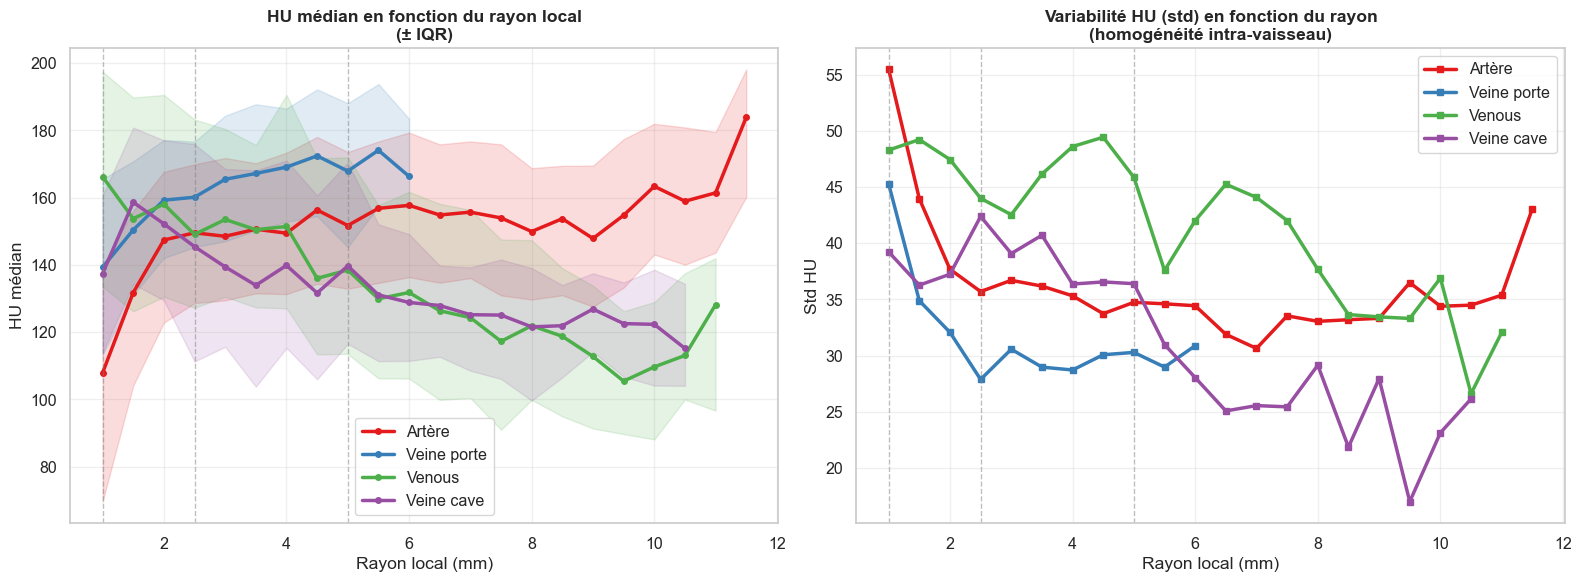

In [59]:
# ─── Fig 6 : HU moyen en fonction du rayon (courbe par type) ───
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# a) Médiane HU vs rayon
ax = axes[0]
ax.set_title('HU médian en fonction du rayon local\n(± IQR)', fontweight='bold')
bins = np.arange(0.25, 12, 0.5)
for lbl, info in VESSEL_LABELS.items():
    r  = profiles[lbl]['radii']
    hu = profiles[lbl]['hu']
    mask_valid = (r > 0) & (r < 15) & (hu > -200) & (hu < 500)
    r, hu = r[mask_valid], hu[mask_valid]
    if len(r) < 100:
        continue
    centers, med, p25, p75 = [], [], [], []
    for b0, b1 in zip(bins[:-1], bins[1:]):
        sel = hu[(r >= b0) & (r < b1)]
        if len(sel) > 10:
            centers.append((b0+b1)/2)
            med.append(np.median(sel))
            p25.append(np.percentile(sel, 25))
            p75.append(np.percentile(sel, 75))
    if centers:
        centers = np.array(centers)
        med = np.array(med)
        ax.plot(centers, med, color=info['color'], lw=2.5, label=info['display'], marker='o', ms=4)
        ax.fill_between(centers, p25, p75, color=info['color'], alpha=0.15)

for thresh in [1.0, 2.5, 5.0]:
    ax.axvline(thresh, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('Rayon local (mm)')
ax.set_ylabel('HU médian')
ax.legend()
ax.grid(alpha=0.3)

# b) Std HU vs rayon (variabilité intra-vaisseau)
ax = axes[1]
ax.set_title('Variabilité HU (std) en fonction du rayon\n(homogénéité intra-vaisseau)', fontweight='bold')
for lbl, info in VESSEL_LABELS.items():
    r  = profiles[lbl]['radii']
    hu = profiles[lbl]['hu']
    mask_valid = (r > 0) & (r < 15) & (hu > -200) & (hu < 500)
    r, hu = r[mask_valid], hu[mask_valid]
    if len(r) < 100:
        continue
    centers, stds = [], []
    for b0, b1 in zip(bins[:-1], bins[1:]):
        sel = hu[(r >= b0) & (r < b1)]
        if len(sel) > 10:
            centers.append((b0+b1)/2)
            stds.append(np.std(sel))
    if centers:
        ax.plot(centers, stds, color=info['color'], lw=2.5, label=info['display'], marker='s', ms=4)

for thresh in [1.0, 2.5, 5.0]:
    ax.axvline(thresh, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('Rayon local (mm)')
ax.set_ylabel('Std HU')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig06_hu_vs_radius_profile.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Analyse par Tranches de Calibre

In [ ]:
# Tableau de statistiques par calibre et par type de vaisseau
records = []

for lbl, info in VESSEL_LABELS.items():
    r  = profiles[lbl]['radii']
    hu = profiles[lbl]['hu']
    mask_valid = (r > 0) & (hu > -500) & (hu < 1000)
    r, hu = r[mask_valid], hu[mask_valid]

    for i, (r_min, r_max) in enumerate(zip(RADIUS_BINS[:-1], RADIUS_BINS[1:])):
        sel_r  = r[(r >= r_min) & (r < r_max)]
        sel_hu = hu[(r >= r_min) & (r < r_max)]
        if len(sel_r) == 0:
            continue
        records.append({
            'Vaisseau':        info['display'],
            'Calibre':         RADIUS_LABELS[i],
            'N voxels skel.':  len(sel_r),
            'Rayon moyen (mm)': f"{sel_r.mean():.2f} ± {sel_r.std():.2f}",
            'Rayon médian':    f"{np.median(sel_r):.2f}",
            'HU moyen':        f"{sel_hu.mean():.1f} ± {sel_hu.std():.1f}",
            'HU médian':       f"{np.median(sel_hu):.1f}",
            'HU P5–P95':       f"[{np.percentile(sel_hu,5):.0f} ; {np.percentile(sel_hu,95):.0f}]",
            '% du vaisseau':   f"{100*len(sel_r)/len(r):.1f}%",
        })

df_calibres = pd.DataFrame(records)

# Affichage
pd.set_option('display.max_colwidth', 30)
print('\n STATISTIQUES PAR CALIBRE ET TYPE DE VAISSEAU')
print('=' * 90)
print(df_calibres.to_string(index=False))
df_calibres.to_csv(os.path.join(OUTPUT_DIR, 'stats_calibre_par_vaisseau.csv'), index=False)
print(f'\n Sauvegardé → stats_calibre_par_vaisseau.csv')


📊 STATISTIQUES PAR CALIBRE ET TYPE DE VAISSEAU
   Vaisseau  Calibre  N voxels skel. Rayon moyen (mm) Rayon médian     HU moyen HU médian   HU P5–P95 % du vaisseau
     Artère 1–2.5 mm           18577      1.36 ± 0.47         1.00 115.7 ± 53.9     124.7  [12 ; 184]         74.9%
     Artère 2.5–5 mm            2202      3.52 ± 0.64         3.16 152.0 ± 41.6     150.3  [98 ; 203]          8.9%
     Artère   > 5 mm            4010      7.70 ± 2.23         7.21 152.7 ± 37.1     155.3  [92 ; 205]         16.2%
Veine porte 1–2.5 mm           57797      1.27 ± 0.43         1.00 144.8 ± 42.6     145.9  [75 ; 211]         91.6%
Veine porte 2.5–5 mm            4935      3.37 ± 0.54         3.00 166.9 ± 30.0     167.2 [118 ; 215]          7.8%
Veine porte   > 5 mm             393      5.20 ± 0.35         5.00 167.4 ± 30.9     167.5 [117 ; 218]          0.6%
     Venous 1–2.5 mm           38402      1.32 ± 0.46         1.00 162.3 ± 48.2     162.6  [84 ; 239]         81.7%
     Venous 2.5–5 mm    

In [68]:
# Affichage détaillé des pourcentages par calibre (y compris < 1 mm)
print("\n" + "="*70)
print("  POURCENTAGES EXACTS PAR CALIBRE (sphère inscrite maximale)")
print("="*70)

for lbl, info in VESSEL_LABELS.items():
    r = profiles[lbl]['radii']
    r = r[r > 0]
    if len(r) == 0:
        continue
    
    total = len(r)
    print(f"\n{info['display']:15s} (n = {total:,})")
    print("-" * 50)
    
    for i, (r_min, r_max) in enumerate(zip(RADIUS_BINS[:-1], RADIUS_BINS[1:])):
        count = ((r >= r_min) & (r < r_max)).sum()
        pct = 100 * count / total
        bar = '█' * int(pct / 2) + '░' * (50 - int(pct / 2))
        label = RADIUS_LABELS[i]
        print(f"  {label:12s} : {bar}  {pct:5.1f}%  ({count:>7,} points)")


  POURCENTAGES EXACTS PAR CALIBRE (sphère inscrite maximale)

Artère          (n = 24,790)
--------------------------------------------------
  < 0.5 mm     : ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%  (      0 points)
  0.5–1 mm     : ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%  (      0 points)
  1–2.5 mm     : █████████████████████████████████████░░░░░░░░░░░░░   74.9%  ( 18,578 points)
  2.5–5 mm     : ████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    8.9%  (  2,202 points)
  > 5 mm       : ████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   16.2%  (  4,010 points)

Veine porte     (n = 63,125)
--------------------------------------------------
  < 0.5 mm     : ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%  (      0 points)
  0.5–1 mm     : ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░    0.0%  (      0 points)
  1–2.5 mm     : █████████████████████████████████████████████░░░░░   91.6%  ( 57,797 points)
  2.5–5 mm     : ███░░░░

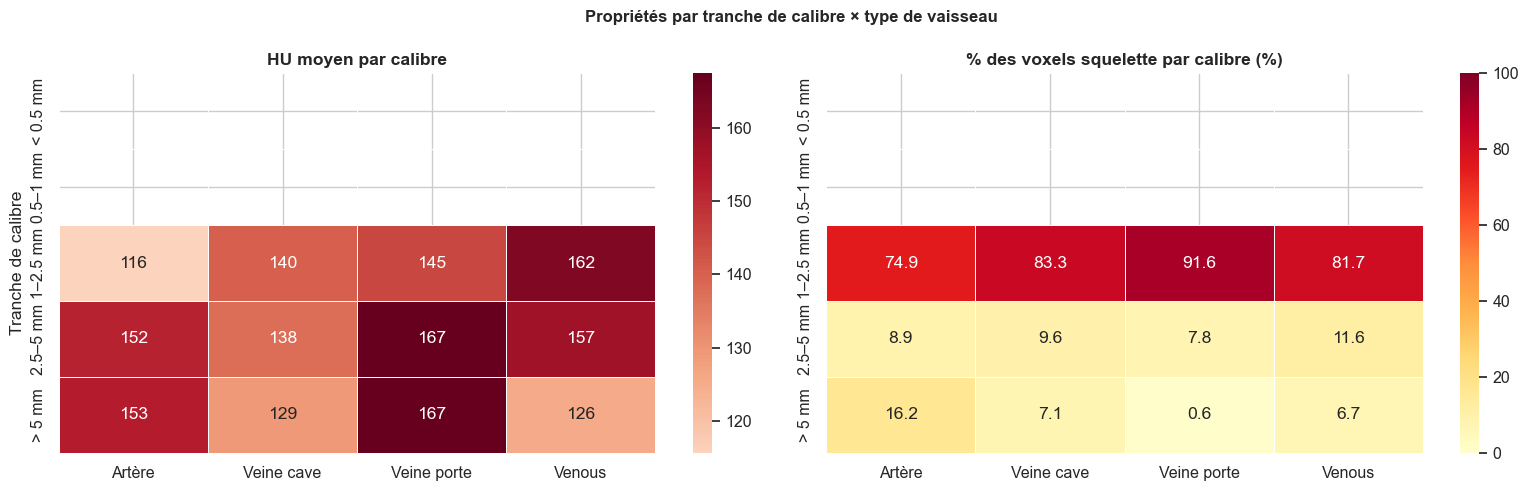

In [61]:
# ─── Fig 7 : Heatmap HU moyen par calibre × vaisseau ───────────
pivot_hu = df_calibres.pivot_table(
    index='Calibre',
    columns='Vaisseau',
    values='HU moyen',
    aggfunc=lambda x: float(x.iloc[0].split('±')[0])
).reindex(RADIUS_LABELS)

pivot_pct = df_calibres.pivot_table(
    index='Calibre',
    columns='Vaisseau',
    values='% du vaisseau',
    aggfunc=lambda x: float(x.iloc[0].replace('%',''))
).reindex(RADIUS_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Propriétés par tranche de calibre × type de vaisseau', fontsize=12, fontweight='bold')

sns.heatmap(pivot_hu.astype(float), annot=True, fmt='.0f', cmap='RdBu_r',
            linewidths=0.5, ax=axes[0], center=100)
axes[0].set_title('HU moyen par calibre', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tranche de calibre')

sns.heatmap(pivot_pct.astype(float), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1],
            vmin=0, vmax=100)
axes[1].set_title('% des voxels squelette par calibre (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig07_heatmap_calibre.png'), dpi=150, bbox_inches='tight')
plt.show()

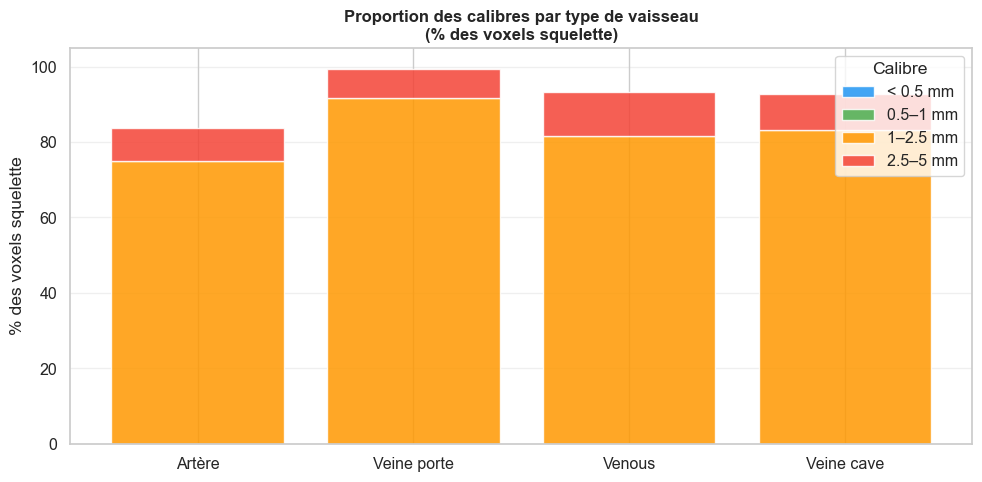

In [62]:
# ─── Fig 8 : Proportion de calibres par type (stacked bar) ──────
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Proportion des calibres par type de vaisseau\n(% des voxels squelette)',
             fontsize=12, fontweight='bold')

calibre_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
vessel_names = [info['display'] for info in VESSEL_LABELS.values()]

bottom = np.zeros(len(VESSEL_LABELS))
for i, (cal_lbl, cal_color) in enumerate(zip(RADIUS_LABELS, calibre_colors)):
    vals = []
    for lbl, info in VESSEL_LABELS.items():
        r = profiles[lbl]['radii']
        r = r[r > 0]
        if len(r) == 0:
            vals.append(0.0)
            continue
        r_min, r_max = RADIUS_BINS[i], RADIUS_BINS[i+1]
        pct = 100 * ((r >= r_min) & (r < r_max)).sum() / len(r)
        vals.append(pct)
    ax.bar(vessel_names, vals, bottom=bottom, color=cal_color, label=cal_lbl, alpha=0.85)
    bottom += np.array(vals)

ax.set_ylabel('% des voxels squelette')
ax.set_ylim(0, 105)
ax.legend(title='Calibre', loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig08_calibre_proportions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Séparabilité Inter-Classes (pour la Segmentation)

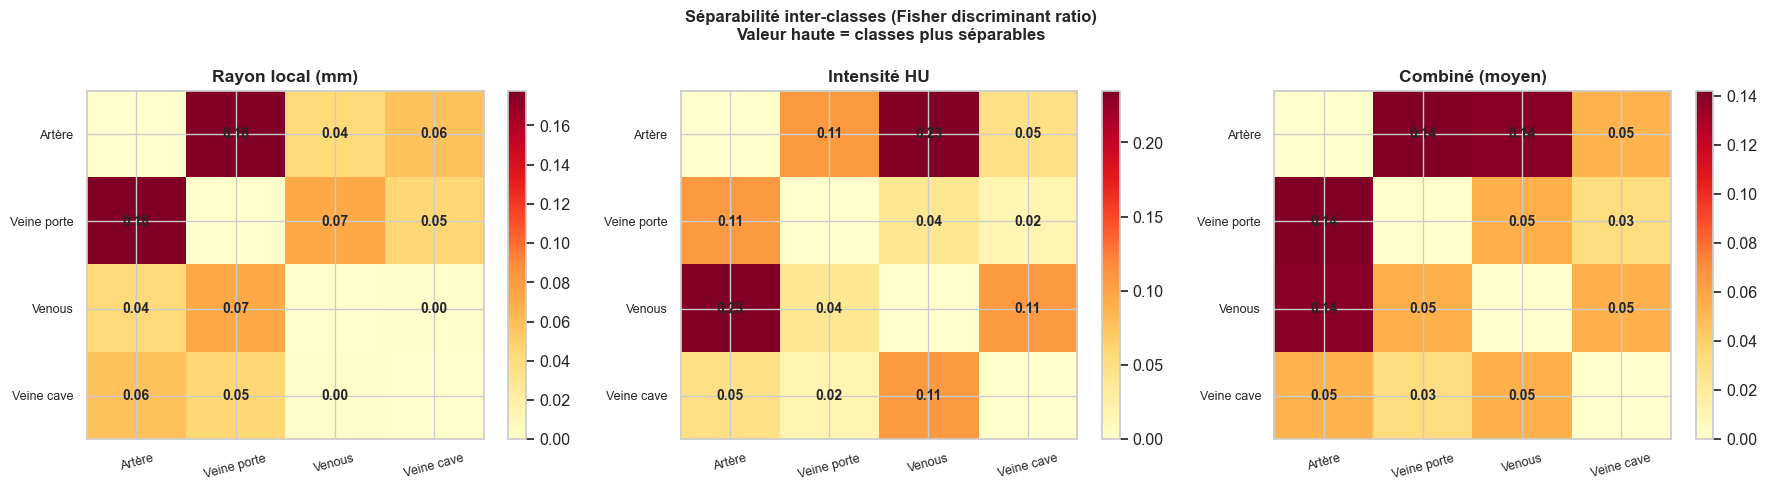


💡 Interprétation :
  Fisher > 1.0 → bonne séparabilité
  Fisher < 0.1 → classes très similaires → difficile à distinguer par ce seul critère


In [63]:
# ─── Fig 9 : Matrice de séparabilité (Fisher score) ─────────────
# Fisher discriminant ratio : (mu1-mu2)^2 / (sig1^2 + sig2^2)

def fisher_score(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return (a.mean() - b.mean())**2 / (a.std()**2 + b.std()**2 + 1e-9)

labels_list = list(VESSEL_LABELS.keys())
n = len(labels_list)

# Matrices pour rayon et HU
M_radius = np.full((n, n), np.nan)
M_hu     = np.full((n, n), np.nan)
M_joint  = np.full((n, n), np.nan)  # Fisher moyen des deux features

for i, l1 in enumerate(labels_list):
    for j, l2 in enumerate(labels_list):
        if i == j:
            continue
        r1  = profiles[l1]['radii'];  r1 = r1[r1>0]
        r2  = profiles[l2]['radii'];  r2 = r2[r2>0]
        h1  = profiles[l1]['hu'];     h1 = h1[(h1>-200)&(h1<500)]
        h2  = profiles[l2]['hu'];     h2 = h2[(h2>-200)&(h2<500)]
        M_radius[i, j] = fisher_score(r1, r2)
        M_hu[i, j]     = fisher_score(h1, h2)
        M_joint[i, j]  = (M_radius[i,j] + M_hu[i,j]) / 2

display_names = [info['display'] for info in VESSEL_LABELS.values()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Séparabilité inter-classes (Fisher discriminant ratio)\nValeur haute = classes plus séparables',
             fontsize=12, fontweight='bold')

for ax, M, title in zip(axes,
                        [M_radius, M_hu, M_joint],
                        ['Rayon local (mm)', 'Intensité HU', 'Combiné (moyen)']):
    mask_nan = np.isnan(M)
    M_plot = np.where(mask_nan, 0, M)
    im = ax.imshow(M_plot, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=ax)
    for i in range(n):
        for j in range(n):
            if not mask_nan[i, j]:
                ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=10, fontweight='bold')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(display_names, rotation=15, fontsize=9)
    ax.set_yticklabels(display_names, fontsize=9)
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig09_separability_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Interprétation :')
print('  Fisher > 1.0 → bonne séparabilité')
print('  Fisher < 0.1 → classes très similaires → difficile à distinguer par ce seul critère')

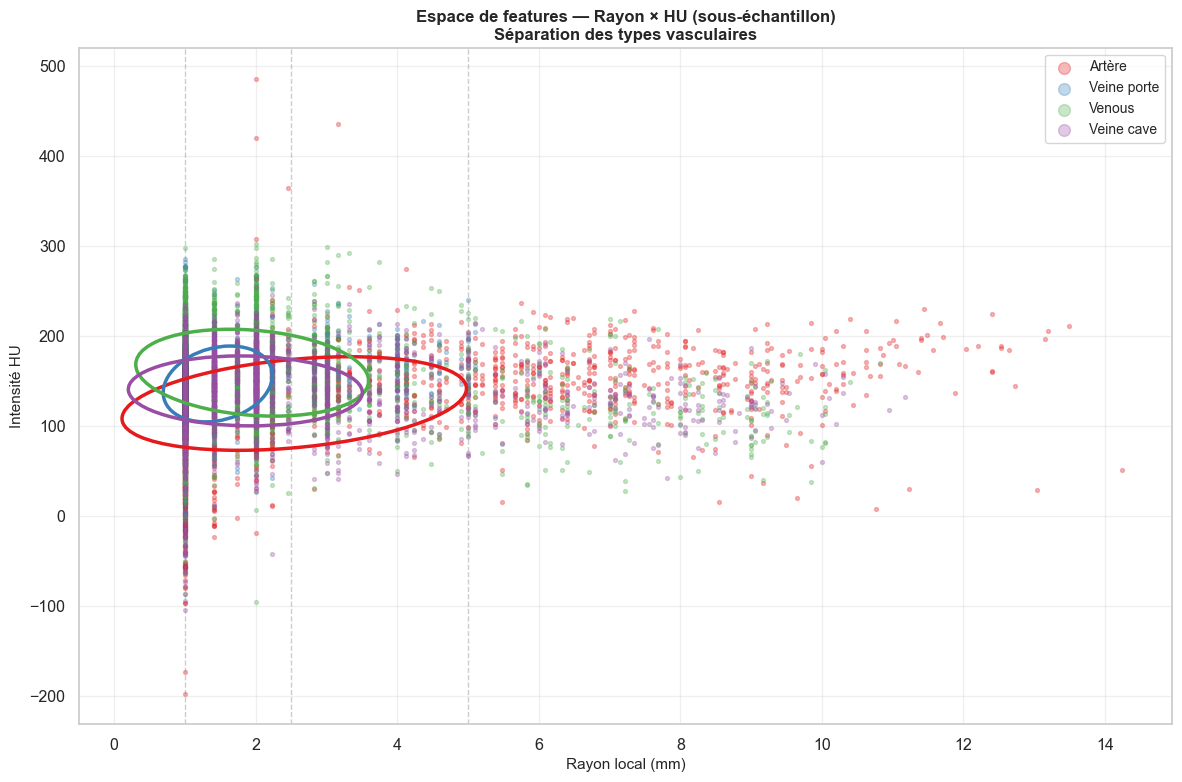

In [64]:
# ─── Fig 10 : Scatter 2D rayon × HU — espace de features ────────
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_title('Espace de features — Rayon × HU (sous-échantillon)\nSéparation des types vasculaires',
             fontsize=12, fontweight='bold')

for lbl, info in VESSEL_LABELS.items():
    r  = profiles[lbl]['radii']
    hu = profiles[lbl]['hu']
    mask_valid = (r > 0) & (r < 15) & (hu > -200) & (hu < 500)
    r, hu = r[mask_valid], hu[mask_valid]
    if len(r) == 0:
        continue
    # Subsample 3000 points max
    n_pts = min(3000, len(r))
    idx = np.random.choice(len(r), n_pts, replace=False)
    ax.scatter(r[idx], hu[idx], c=info['color'], alpha=0.3, s=8, label=info['display'])

    # Ellipse de confiance (1 sigma)
    from matplotlib.patches import Ellipse
    cov = np.cov(r, hu)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * np.sqrt(vals)
    ell = Ellipse((r.mean(), hu.mean()), width=w, height=h, angle=theta,
                  edgecolor=info['color'], facecolor='none', lw=2.5, zorder=5)
    ax.add_patch(ell)

for thresh in [1.0, 2.5, 5.0]:
    ax.axvline(thresh, color='gray', ls='--', lw=1, alpha=0.4)

ax.set_xlabel('Rayon local (mm)', fontsize=11)
ax.set_ylabel('Intensité HU', fontsize=11)
ax.legend(fontsize=10, markerscale=3)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_feature_space.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Analyse des Seuils de Segmentation

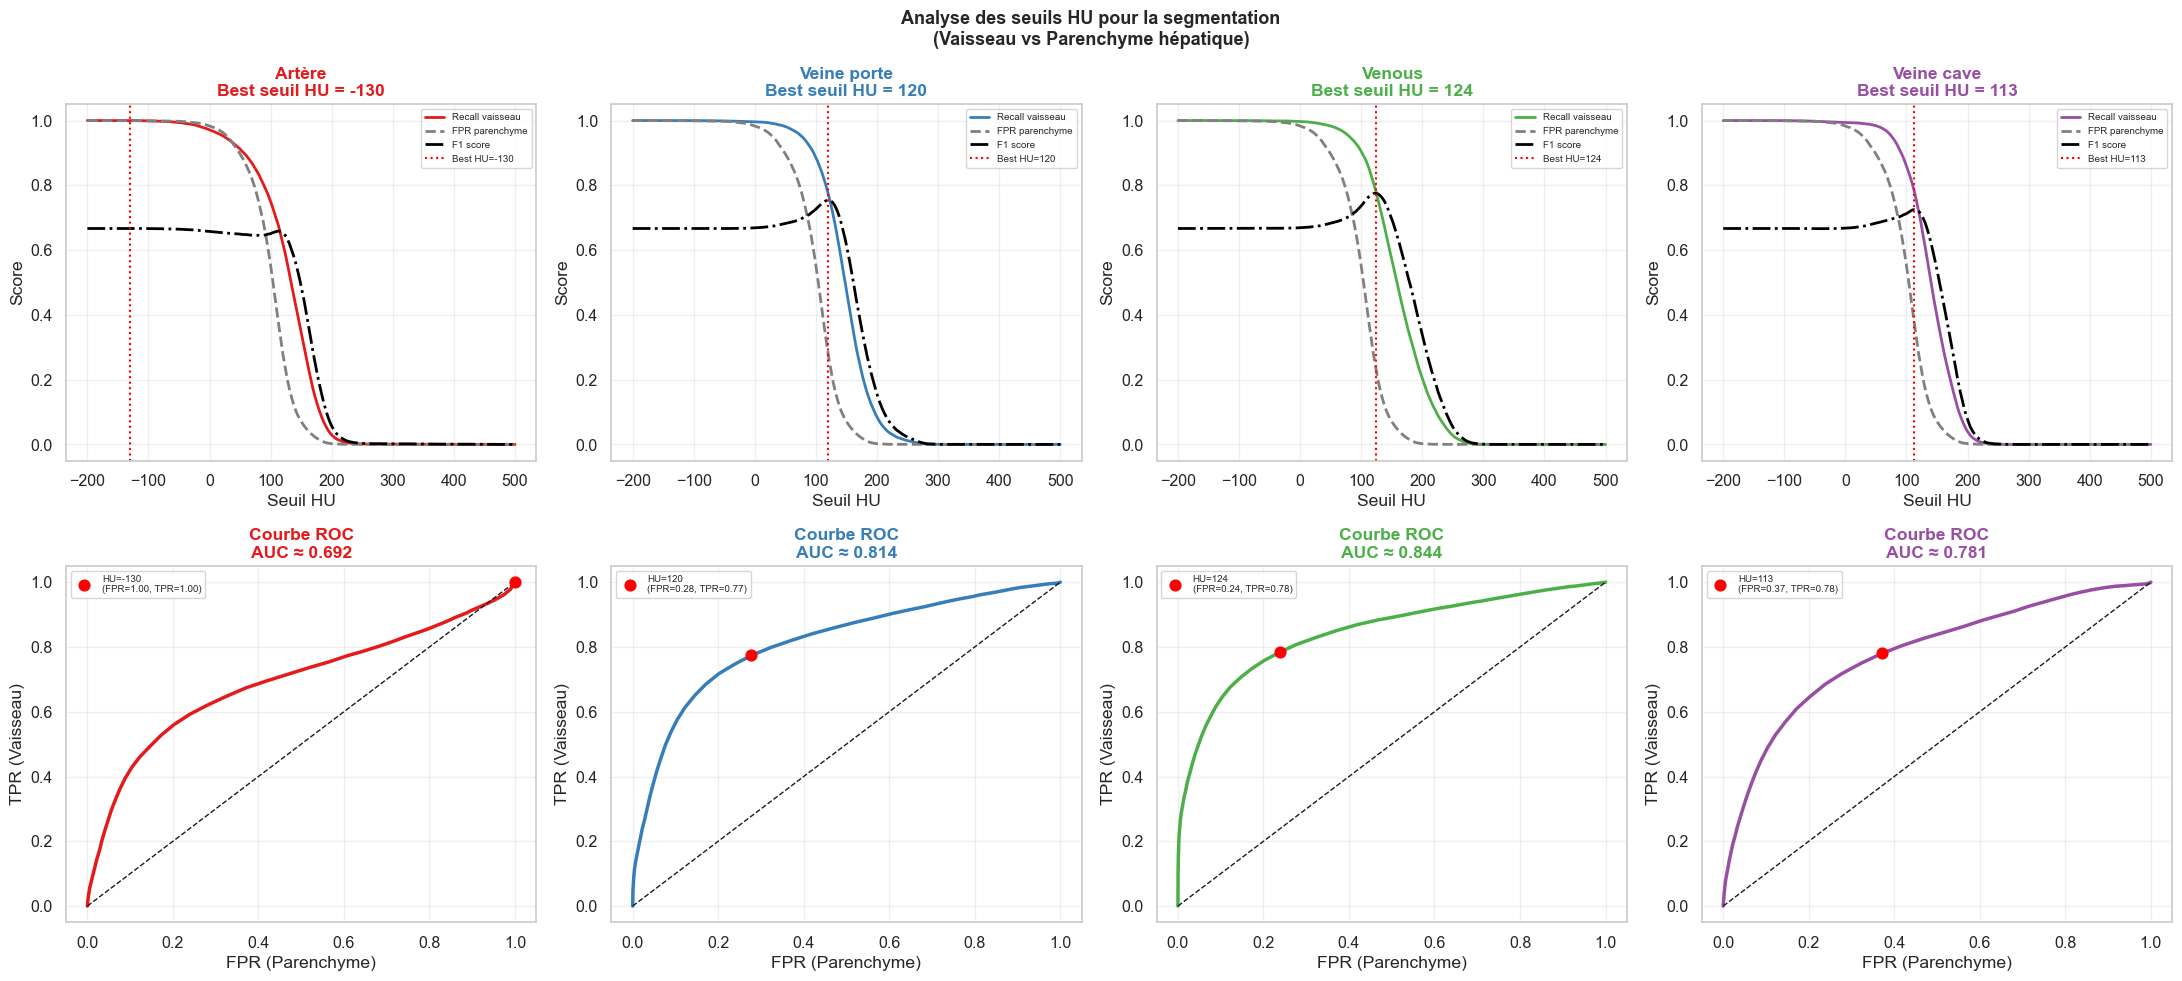

In [65]:
# ─── Fig 11 : Seuils HU optimaux vaisseau vs parenchyme ─────────
# Pour chaque type : courbe TPR/FPR en fonction du seuil HU

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Analyse des seuils HU pour la segmentation\n(Vaisseau vs Parenchyme hépatique)',
             fontsize=13, fontweight='bold')

parc_sample = parenchyma_hu[(parenchyma_hu > -200) & (parenchyma_hu < 500)]
if len(parc_sample) > 20000:
    parc_sample = np.random.choice(parc_sample, 20000, replace=False)

hu_thresholds = np.linspace(-200, 500, 200)

for col_idx, (lbl, info) in enumerate(VESSEL_LABELS.items()):
    hu = profiles[lbl]['hu']
    hu = hu[(hu > -200) & (hu < 500)]
    if len(hu) < 10:
        continue
    if len(hu) > 20000:
        hu = np.random.choice(hu, 20000, replace=False)

    # Courbe Recall (TPR) : fraction du vaisseau au-dessus du seuil
    recall    = np.array([(hu >= t).mean()     for t in hu_thresholds])
    fpr       = np.array([(parc_sample >= t).mean() for t in hu_thresholds])
    precision = recall / (recall + fpr + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    best_t_idx = np.argmax(f1)
    best_t     = hu_thresholds[best_t_idx]

    ax_top = axes[0, col_idx]
    ax_top.plot(hu_thresholds, recall,    color=info['color'], lw=2, label='Recall vaisseau')
    ax_top.plot(hu_thresholds, fpr,       color='gray',        lw=2, ls='--', label='FPR parenchyme')
    ax_top.plot(hu_thresholds, f1,        color='black',       lw=2, ls='-.',  label='F1 score')
    ax_top.axvline(best_t, color='red', lw=1.5, ls=':', label=f'Best HU={best_t:.0f}')
    ax_top.set_title(f'{info["display"]}\nBest seuil HU = {best_t:.0f}',
                     fontweight='bold', color=info['color'])
    ax_top.set_xlabel('Seuil HU')
    ax_top.set_ylabel('Score')
    ax_top.legend(fontsize=7)
    ax_top.grid(alpha=0.3)

    # Courbe ROC
    ax_bot = axes[1, col_idx]
    ax_bot.plot(fpr, recall, color=info['color'], lw=2.5)
    # Marquer le meilleur point
    ax_bot.scatter(fpr[best_t_idx], recall[best_t_idx], color='red', zorder=5, s=60,
                   label=f'HU={best_t:.0f}\n(FPR={fpr[best_t_idx]:.2f}, TPR={recall[best_t_idx]:.2f})')
    ax_bot.plot([0, 1], [0, 1], 'k--', lw=1)
    # AUC approx
    auc = np.trapz(recall[::-1], fpr[::-1])
    ax_bot.set_title(f'Courbe ROC\nAUC ≈ {auc:.3f}', fontweight='bold', color=info['color'])
    ax_bot.set_xlabel('FPR (Parenchyme)')
    ax_bot.set_ylabel('TPR (Vaisseau)')
    ax_bot.legend(fontsize=7)
    ax_bot.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig11_thresholds_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

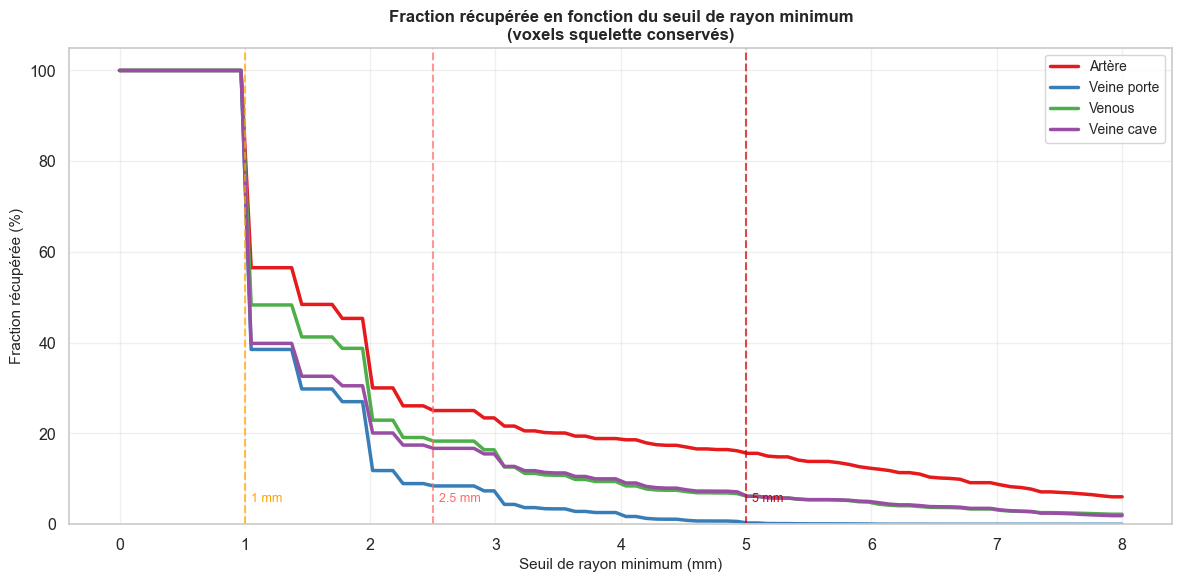

In [66]:
# ─── Fig 12 : Seuils de rayon optimal pour isoler les vaisseaux ─
# Quelle fraction est récupérée selon le seuil de rayon minimum ?

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title('Fraction récupérée en fonction du seuil de rayon minimum\n(voxels squelette conservés)',
             fontsize=12, fontweight='bold')

r_thresholds = np.linspace(0, 8, 100)

for lbl, info in VESSEL_LABELS.items():
    r = profiles[lbl]['radii']
    r = r[r > 0]
    if len(r) == 0:
        continue
    # Fraction ≥ seuil
    frac = np.array([(r >= t).mean() for t in r_thresholds])
    ax.plot(r_thresholds, frac * 100, color=info['color'], lw=2.5, label=info['display'])

for thresh, col_t, lbl_t in zip([1.0, 2.5, 5.0],
                                 ['#FFA500','#FF6B6B','#CC0000'],
                                 ['1 mm', '2.5 mm', '5 mm']):
    ax.axvline(thresh, color=col_t, ls='--', lw=1.5, alpha=0.7)
    ax.text(thresh+0.05, 5, lbl_t, color=col_t, fontsize=9)

ax.set_xlabel('Seuil de rayon minimum (mm)', fontsize=11)
ax.set_ylabel('Fraction récupérée (%)', fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_radius_threshold_recovery.png'), dpi=150, bbox_inches='tight')
plt.show()